# Morning Momentum Research

## Objective

This notebook investigates whether returns generated during the morning session contain predictive information about returns later in the day.

The study focuses on persistence, reversal, and intraday momentum effects.

## Research Question

Do strong morning moves continue into the afternoon session?

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./NIFTY_50_minute.csv")

df['date'] = pd.to_datetime(
    df['date'],
    format='%d-%m-%Y %H:%M'
)

df = df.sort_values('date')
df = df.set_index('date')

df.head()

,open,high,low,close,volume
date,,,,,
2015-01-09 09:15:00,8285.45,8295.90,8285.45,8292.10,0
2015-01-09 09:16:00,8292.60,8293.60,8287.20,8288.15,0
2015-01-09 09:17:00,8287.40,8293.90,8287.40,8293.90,0
2015-01-09 09:18:00,8294.25,8300.65,8293.90,8300.65,0
2015-01-09 09:19:00,8300.60,8301.30,8298.75,8301.20,0


In [20]:
# ============================================================
# DATA CLEANING
# ============================================================

market_open = pd.Timestamp("09:15").time()
market_close = pd.Timestamp("15:29").time()

df = df[
    (df.index.time >= market_open) &
    (df.index.time <= market_close)
].copy()

df = df[
    ~df.index.duplicated(keep="first")
]

print("Rows:", len(df))
print("Start:", df.index.min())
print("End:", df.index.max())

Rows: 974705
Start: 2015-01-09 09:15:00
End: 2025-07-25 15:29:00


# Signal Construction

Morning returns are calculated over the early trading session and used as the primary predictive signal.

The hypothesis is that strong directional movement during the morning may influence afternoon price behavior.

In [21]:
research = []

for day, day_df in df.groupby(df.index.date):

    open_bar = day_df.between_time(
        "09:15",
        "09:15"
    )

    morning_bar = day_df.between_time(
        "11:00",
        "11:00"
    )

    close_bar = day_df.between_time(
        "15:15",
        "15:15"
    )

    if (
        len(open_bar)==0
        or len(morning_bar)==0
        or len(close_bar)==0
    ):
        continue

    day_open = open_bar.iloc[0]['open']

    morning_close = morning_bar.iloc[0]['close']

    day_close = close_bar.iloc[0]['close']

    morning_return = (
        morning_close/day_open - 1
    )

    afternoon_return = (
        day_close/morning_close - 1
    )

    research.append(
        [
            day,
            morning_return,
            afternoon_return
        ]
    )

research = pd.DataFrame(
    research,
    columns=[
        'date',
        'morning_return',
        'afternoon_return'
    ]
)

research.head()

,date,morning_return,afternoon_return
0,2015-01-09,0.000278,-0.000278
1,2015-01-12,-0.000476,0.004006
2,2015-01-13,-0.000821,-0.004329
3,2015-01-14,-0.000536,-0.003926
4,2015-01-15,-0.000771,0.010637


In [22]:
research['bucket'] = pd.qcut(
    research['morning_return'],
    5,
    labels=[
        'Very Negative',
        'Negative',
        'Neutral',
        'Positive',
        'Very Positive'
    ]
)

research.groupby(
    'bucket'
)['afternoon_return'].mean()




bucket
Very Negative   -0.001009
Negative        -0.000402
Neutral         -0.000362
Positive         0.000128
Very Positive    0.000878
Name: afternoon_return, dtype: float64

In [23]:
research['abs_morning'] = (
    research['morning_return']
    .abs()
)

research['bucket'] = pd.qcut(
    research['abs_morning'],
    5,
    labels=[
        'Very Small',
        'Small',
        'Medium',
        'Large',
        'Very Large'
    ]
)

research.groupby(
    'bucket'
)['afternoon_return'].agg(
    ['mean','count']
)

,mean,count
bucket,,
Very Small,-0.000364,520
Small,-0.000053,519
Medium,0.000183,519
Large,-0.000513,519
Very Large,-0.000021,519


# Bucket Analysis

To understand the relationship between signal strength and future returns, observations are grouped into return buckets.

This allows the analysis of how future performance changes across different signal regimes.

In [24]:
import numpy as np

bins = [
    -np.inf,
    -0.01,
    -0.005,
    0,
    0.005,
    0.01,
    np.inf
]

labels = [
    "< -1%",
    "-1% to -0.5%",
    "-0.5% to 0%",
    "0% to 0.5%",
    "0.5% to 1%",
    "> 1%"
]

research['bucket'] = pd.cut(
    research['morning_return'],
    bins=bins,
    labels=labels
)

result = (
    research
    .groupby('bucket')
    ['afternoon_return']
    .agg(['mean','median','count'])
)

print(result)

                  mean    median  count
bucket                                 
< -1%        -0.001808 -0.000847     62
-1% to -0.5% -0.000943 -0.000798    300
-0.5% to 0%  -0.000387 -0.000166   1063
0% to 0.5%    0.000066  0.000326    950
0.5% to 1%    0.001150  0.001215    194
> 1%          0.004511  0.002473     27


In [29]:
import os

os.makedirs(
    "results",
    exist_ok=True
)

result.to_csv(
    "results/bucket_analysis.csv"
)

print("Saved!")

Saved!


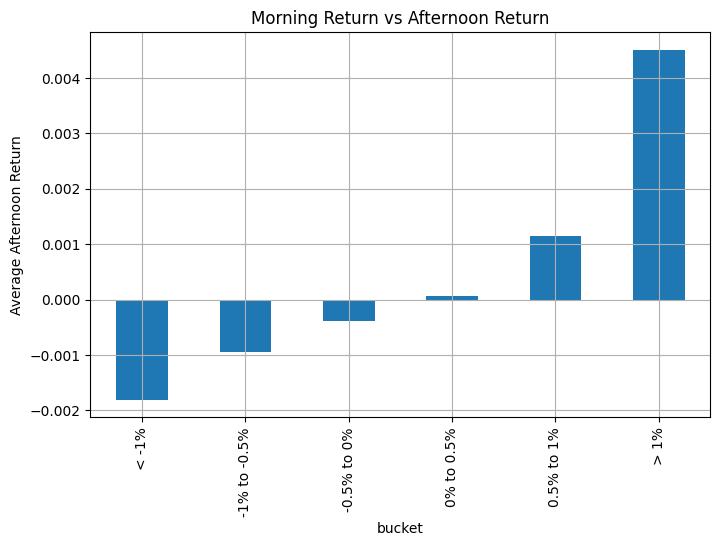

In [30]:
result['mean'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Morning Return vs Afternoon Return')
plt.ylabel('Average Afternoon Return')
plt.grid(True)
plt.show()

In [31]:
import plotly.express as px

fig = px.scatter(
    research,
    x="morning_return",
    y="afternoon_return",
    hover_data=["date"],
    title="Morning Return vs Afternoon Return",
    trendline="ols"
)

fig.update_layout(
    xaxis_title="Morning Return (%)",
    yaxis_title="Afternoon Return (%)"
)

fig.show()

Saved!


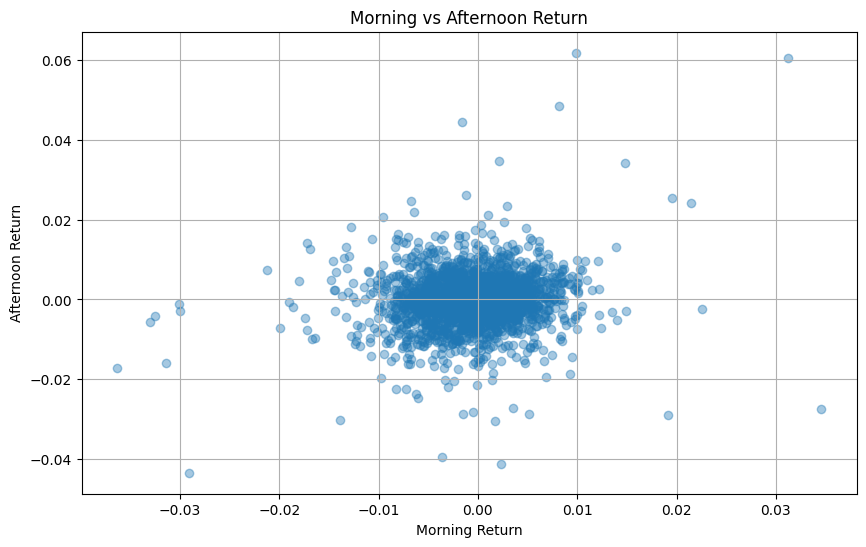

In [ ]:
import os

os.makedirs(
    "plots",
    exist_ok=True
)

import plotly.io as pio

pio.write_html(
    fig,
    "plots/morning_afternoon_scatter.html"
)

print("Saved!")



plt.figure(figsize=(10,6))

plt.scatter(
    research["morning_return"],
    research["afternoon_return"],
    alpha=0.4
)

plt.xlabel("Morning Return")
plt.ylabel("Afternoon Return")
plt.title("Morning vs Afternoon Return")

plt.grid(True)

plt.savefig(
    "plots/morning_afternoon_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Regime Stability Analysis

A useful signal should remain effective across different market environments.

Performance is therefore evaluated separately across multiple historical periods.

In [41]:
research["year"] = pd.to_datetime(
    research["date"]
).dt.year

periods = {
    "2015-2019": (2015, 2019),
    "2020-2022": (2020, 2022),
    "2023-2025": (2023, 2025)
}

for name, (start, end) in periods.items():

    temp = research[
        (research["year"] >= start) &
        (research["year"] <= end)
    ]

    corr = temp["morning_return"].corr(
        temp["afternoon_return"]
    )

    print(name, round(corr, 3))

2015-2019 0.165
2020-2022 0.128
2023-2025 0.059


In [42]:
corr_df = pd.DataFrame({
    "Period": [
        "2015-2019",
        "2020-2022",
        "2023-2025"
    ],
    "Correlation": [
        0.165,
        0.128,
        0.059
    ]
})

corr_df.to_csv(
    "results/correlation_by_regime.csv",
    index=False
)

# Conclusions

## Research Question

Do morning returns contain predictive information about afternoon returns?

## Evidence

- Positive relationship observed between morning and afternoon returns.
- Strong signals produced better average afternoon performance.
- Predictability weakened significantly after 2023.
- Recent regime performance deteriorated compared to earlier periods.

## Verdict

🟡 Partially Accepted

Morning momentum exhibits predictive power, but the effect is unstable across market regimes and has weakened in recent years.

The signal should not be used as a standalone trading strategy.